In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skdim
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

import xarray as xr
import rioxarray
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

def save_to_geotiff(data, x_coord, y_coord, filename):
    # Create an xarray DataArray
    da = xr.DataArray(data, coords=[('y', y_coord), ('x', x_coord)])
    
    # Save to GeoTIFF using rioxarray
    da.rio.to_raster(filename)

%load_ext autoreload
%autoreload 2

# load data
# get the DATA_PATH from the environment variable
data_path  = os.getenv('DATA_PATH')
param_path = os.getenv('PARAM_PATH')
folder = data_path
X_filename = 'trainingAll4D_Eb_sim_standardized.mat'
Y_filename = 'trainingAll4D_Ns_sim_masked_standardized.mat'
H_filename = 'H_gridded.mat'
mask_filename = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename = 'trainingAll_Ns_sim_std_masked.mat'
coord_filename = "trainingAll_image_coord.mat"
# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


X_data = scipy.io.loadmat(folder + X_filename)
Y_data = scipy.io.loadmat(folder + Y_filename)
mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename)
coord_data = scipy.io.loadmat(folder + coord_filename)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704


Shape of Eb_standardized: (256, 256, 1, 1042)
Shape of Ns_standardized: (256, 256, 1, 1042)
Shape of mask: (256, 256)


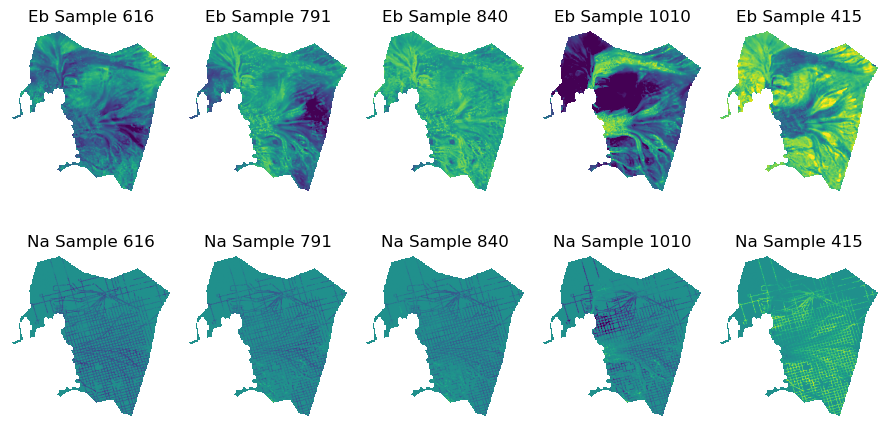

In [19]:
x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

Eb_standardized = X_data['Eb_standardized']
Ns_standardized = Y_data['Ns_standardized_masked']
mask = mask_data['mask']
mask_bool = mask.astype(bool)
print('Shape of Eb_standardized:', Eb_standardized.shape)
print('Shape of Ns_standardized:', Ns_standardized.shape)
print('Shape of mask:', mask.shape)

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(float)

# initialize the model object
md = model.model()
md.load_data(Eb_standardized, Ns_standardized, mask=model_bound_data_ori, show_plot=True)

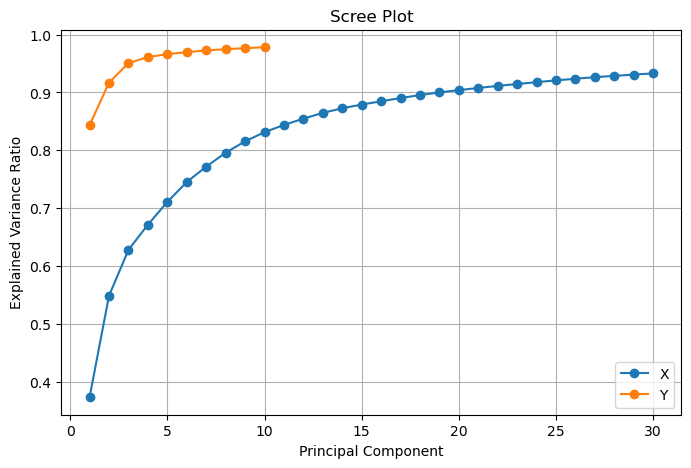

In [20]:
md.pca_scree(n_component_x=30, n_component_y=10)

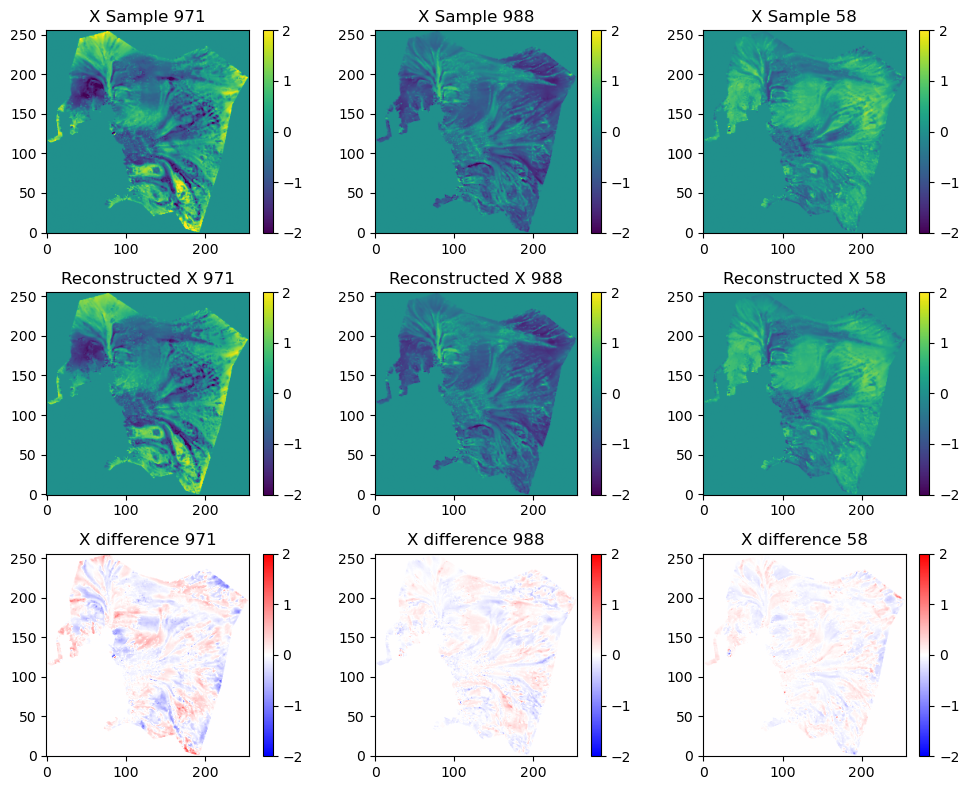

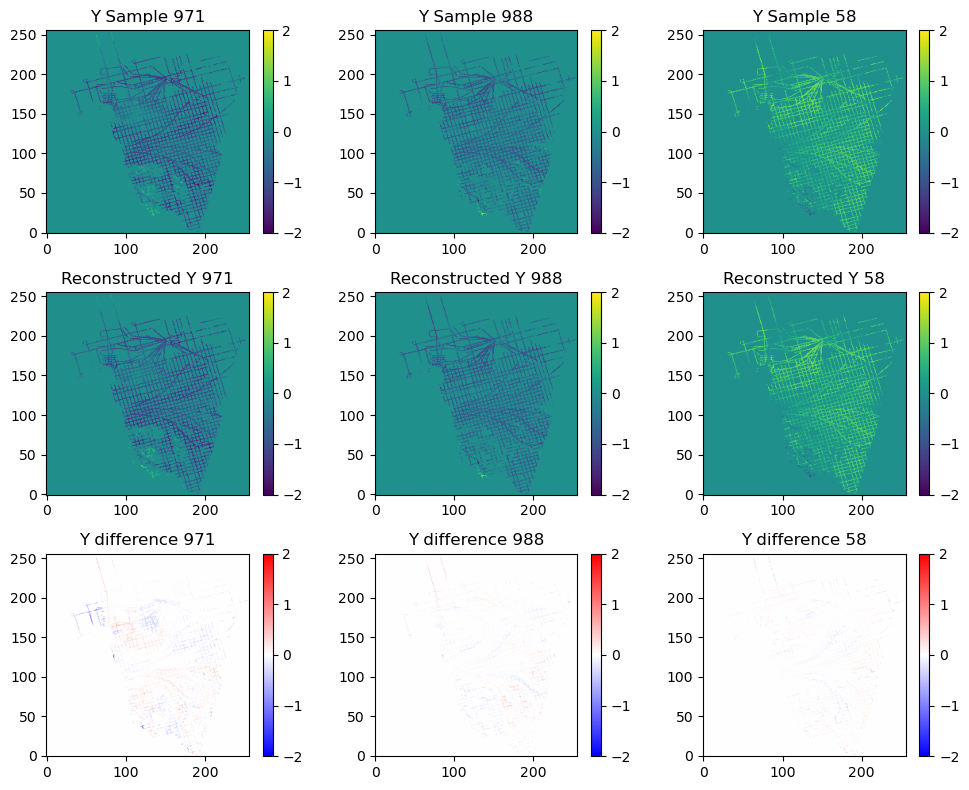

In [21]:
md.pca_recon_inspection(n_component_x=30, n_component_y=10)

In [22]:
md.reduce(n_component_x=25, n_component_y=8)
md.data_split(train_ratio=0.8, validation_ratio=0.1, test_ratio=0.1)
md.train_gmm(n_components=25)

Shape of XY_train: (833, 33)
Shape of XY_validation: (104, 33)
Shape of XY_test: (105, 33)
GMM training completed in 0.14 seconds.
